In [3]:
import cv2
import numpy as np

def get_sift_matches(imgA_gray, imgB_gray, ratio=0.75, max_matches=50):
    # SIFT for rich features. If not available, fallback to ORB.
    try:
        sift = cv2.SIFT_create()
        kpA, desA = sift.detectAndCompute(imgA_gray, None)
        kpB, desB = sift.detectAndCompute(imgB_gray, None)
        norm = cv2.NORM_L2
    except Exception:
        orb = cv2.ORB_create(5000)
        kpA, desA = orb.detectAndCompute(imgA_gray, None)
        kpB, desB = orb.detectAndCompute(imgB_gray, None)
        norm = cv2.NORM_HAMMING

    bf = cv2.BFMatcher(norm, crossCheck=False)
    raw = bf.knnMatch(desA, desB, k=2)

    good = []
    for m, n in raw:
        if m.distance < ratio * n.distance:
            good.append(m)

    good = sorted(good, key=lambda m: m.distance)[:max_matches]

    ptsA = np.float32([kpA[m.queryIdx].pt for m in good])
    ptsB = np.float32([kpB[m.trainIdx].pt for m in good])
    return ptsA, ptsB, good, kpA, kpB


In [4]:

def _normalize_points(pts):
    # pts: N x 2
    mean = np.mean(pts, axis=0)
    std = np.std(pts, axis=0).mean()
    if std < 1e-8:
        std = 1.0
    s = np.sqrt(2) / std
    T = np.array([[s, 0, -s*mean[0]],
                  [0, s, -s*mean[1]],
                  [0, 0, 1]], dtype=np.float64)
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
    npts = (T @ pts_h.T).T[:, :2]
    return npts, T

def _dlt_homography(pts_src, pts_dst):
    # expects at least 4 correspondences
    n = pts_src.shape[0]
    A = []
    for i in range(n):
        x, y = pts_src[i]
        u, v = pts_dst[i]
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])
        A.append([x, y, 1, 0, 0, 0, -u*x, -u*y, -u])
    A = np.asarray(A, dtype=np.float64)
    # Solve Ah=0, h is last right singular vector
    _, _, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H = h.reshape(3, 3)
    return H

def homography_DLT_normalized(pts_src, pts_dst):
    # Normalize
    nsrc, Tsrc = _normalize_points(pts_src)
    ndst, Tdst = _normalize_points(pts_dst)
    # DLT on normalized points
    Hn = _dlt_homography(nsrc, ndst)
    # Denormalize: H = Tdst^{-1} * Hn * Tsrc
    H = np.linalg.inv(Tdst) @ Hn @ Tsrc
    # Scale so H[2,2] = 1 for stability
    if abs(H[2,2]) > 1e-12:
        H = H / H[2,2]
    return H

In [ ]:
def compute_reprojection_errors(pts_src, pts_dst, H):
    # Project src -> dst and compute Euclidean reprojection error
    n = pts_src.shape[0]
    src_h = np.hstack([pts_src, np.ones((n,1))])  # N x 3
    proj_h = (H @ src_h.T).T
    proj = proj_h[:, :2] / proj_h[:, 2:3]
    err = np.linalg.norm(proj - pts_dst, axis=1)
    return err

def ransac_homography(pts_src, pts_dst, max_iters=2000, thresh=3.0, conf=0.995):
    # Standard RANSAC loop
    n = pts_src.shape[0]
    if n < 4:
        raise ValueError("Not enough correspondences for homography")

    best_inliers = None
    best_H = None
    rng = np.random.default_rng(1234)

    for it in range(max_iters):
        idx = rng.choice(n, size=4, replace=False)
        H_try = homography_DLT_normalized(pts_src[idx], pts_dst[idx])
        errs = compute_reprojection_errors(pts_src, pts_dst, H_try)
        inliers = errs < thresh

        if best_inliers is None or np.count_nonzero(inliers) > np.count_nonzero(best_inliers):
            best_inliers = inliers
            # Optional early break using adaptive RANSAC could go here

    if best_inliers is None or np.count_nonzero(best_inliers) < 4:
        raise RuntimeError("RANSAC failed to find a valid homography")

    # Refit on all inliers with normalized DLT
    H_best = homography_DLT_normalized(pts_src[best_inliers], pts_dst[best_inliers])
    return H_best, best_inliers

In [6]:
def bilinear_sample(img, x, y):
    # img HxWxC, x and y are floats in image coords
    h, w = img.shape[:2]
    if x < 0 or y < 0 or x >= w-1 or y >= h-1:
        return None

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    x1 = x0 + 1
    y1 = y0 + 1

    dx = x - x0
    dy = y - y0

    Ia = img[y0, x0].astype(np.float64)
    Ib = img[y0, x1].astype(np.float64)
    Ic = img[y1, x0].astype(np.float64)
    Id = img[y1, x1].astype(np.float64)

    top = Ia*(1-dx) + Ib*dx
    bottom = Ic*(1-dx) + Id*dx
    val = top*(1-dy) + bottom*dy
    return np.clip(val, 0, 255)

def warp_src_onto_canvas(src, dst_rgb, H_src_to_dst):
    hD, wD = dst_rgb.shape[:2]
    hS, wS = src.shape[:2]

    # corners in homogeneous coords
    src_corners = np.array([[0,0,1],[wS,0,1],[wS,hS,1],[0,hS,1]], dtype=np.float64).T
    dst_corners = np.array([[0,0,1],[wD,0,1],[wD,hD,1],[0,hD,1]], dtype=np.float64).T

    # map src corners to dst frame
    src_to_dst = H_src_to_dst @ src_corners
    src_to_dst = src_to_dst[:2, :] / src_to_dst[2:3, :]

    # stack with dst corners to find overall bounding box
    all_x = np.hstack([src_to_dst[0], dst_corners[0]])
    all_y = np.hstack([src_to_dst[1], dst_corners[1]])
    min_x, min_y = np.floor([all_x.min(), all_y.min()]).astype(int)
    max_x, max_y = np.ceil([all_x.max(), all_y.max()]).astype(int)

    # translation so that min coords map to 0
    tx = -min_x if min_x < 0 else 0
    ty = -min_y if min_y < 0 else 0

    canvas_w = max_x + tx
    canvas_h = max_y + ty

    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    dst_layer = np.zeros_like(canvas, dtype=np.uint8)
    mask_dst = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    mask_src = np.zeros((canvas_h, canvas_w), dtype=np.uint8)

    # Paste dst into canvas
    x0, y0 = tx, ty
    dst_layer[y0:y0+hD, x0:x0+wD] = dst_rgb
    mask_dst[y0:y0+hD, x0:x0+wD] = 255

    # Inverse mapping: p_src = H^-1 * (p_canvas - translation)
    T = np.array([[1, 0, tx],
                  [0, 1, ty],
                  [0, 0, 1]], dtype=np.float64)
    H_c_to_s = np.linalg.inv(H_src_to_dst) @ np.linalg.inv(T)

    for y in range(canvas_h):
        for x in range(canvas_w):
            p_c = np.array([x, y, 1.0], dtype=np.float64)
            p_s = H_c_to_s @ p_c
            if abs(p_s[2]) < 1e-9:
                continue
            xs = p_s[0] / p_s[2]
            ys = p_s[1] / p_s[2]
            val = bilinear_sample(src, xs, ys)
            if val is not None:
                canvas[y, x] = val.astype(np.uint8)
                mask_src[y, x] = 255

    # Merge
    out = np.zeros_like(canvas)
    both = (mask_src > 0) & (mask_dst > 0)
    only_src = (mask_src > 0) & ~both
    only_dst = (mask_dst > 0) & ~both

    out[only_src] = canvas[only_src]
    out[only_dst] = dst_layer[only_dst]
    out[both] = ((canvas[both].astype(np.float32) + dst_layer[both].astype(np.float32)) / 2).astype(np.uint8)
    return out


def stitch(img_src_bgr, img_dst_bgr, ratio=0.75, ransac_thresh=3.0, ransac_iters=2000):
    src_rgb = cv2.cvtColor(img_src_bgr, cv2.COLOR_BGR2RGB)
    dst_rgb = cv2.cvtColor(img_dst_bgr, cv2.COLOR_BGR2RGB)
    src_gray = cv2.cvtColor(img_src_bgr, cv2.COLOR_BGR2GRAY)
    dst_gray = cv2.cvtColor(img_dst_bgr, cv2.COLOR_BGR2GRAY)

    ptsA, ptsB, matches, kpA, kpB = get_sift_matches(src_gray, dst_gray, ratio=ratio)
    H, inliers = ransac_homography(ptsA, ptsB, max_iters=ransac_iters, thresh=ransac_thresh)

    mosaic = warp_src_onto_canvas(src_rgb, dst_rgb, H)
    return mosaic, H, (ptsA, ptsB, inliers)

In [14]:
def stitch_three(img1_bgr, img2_bgr, img3_bgr, ratio=0.75, ransac_thresh=3.0, ransac_iters=2000):
    # stitch first two (stitch returns RGB mosaic)
    stitched12, H12, inliers12 = stitch(img1_bgr, img2_bgr, ratio=ratio, ransac_thresh=ransac_thresh, ransac_iters=ransac_iters)

    # prepare grayscale versions for matching (stitched12 is RGB)
    stitched_gray = cv2.cvtColor(stitched12, cv2.COLOR_RGB2GRAY)
    img3_rgb = cv2.cvtColor(img3_bgr, cv2.COLOR_BGR2RGB)
    img3_gray = cv2.cvtColor(img3_bgr, cv2.COLOR_BGR2GRAY)

    # compute matches with img3 as source and stitched as destination so H maps img3 -> stitched
    ptsA, ptsB, matches, kpA, kpB = get_sift_matches(img3_gray, stitched_gray, ratio=ratio)
    H_img3_to_stitched, inliers = ransac_homography(ptsA, ptsB, max_iters=ransac_iters, thresh=ransac_thresh)

    # warp img3 (RGB) onto the stitched canvas using a homography that maps img3 -> stitched
    stitched123 = warp_src_onto_canvas(img3_rgb, stitched12, H_img3_to_stitched)

    return stitched123, (H12, H_img3_to_stitched, inliers)


Stitching first two images (1 and 2)...


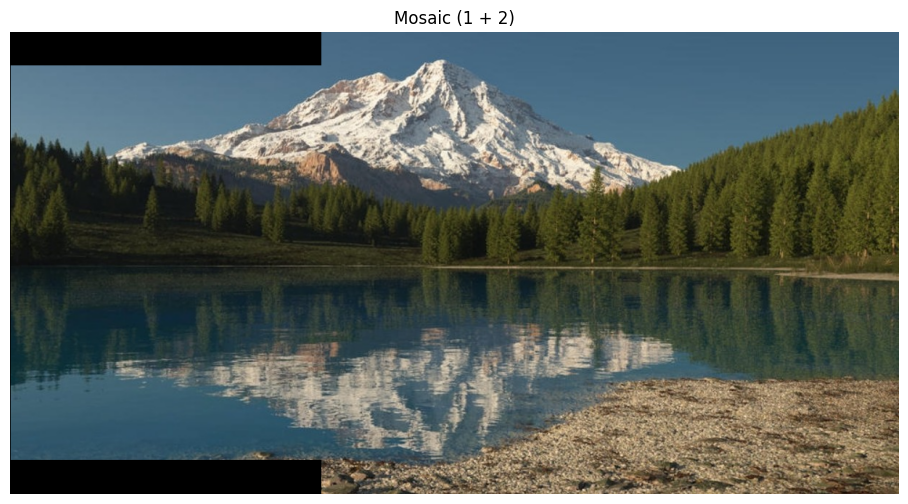

Stitching the mosaic (1+2) with image 3...


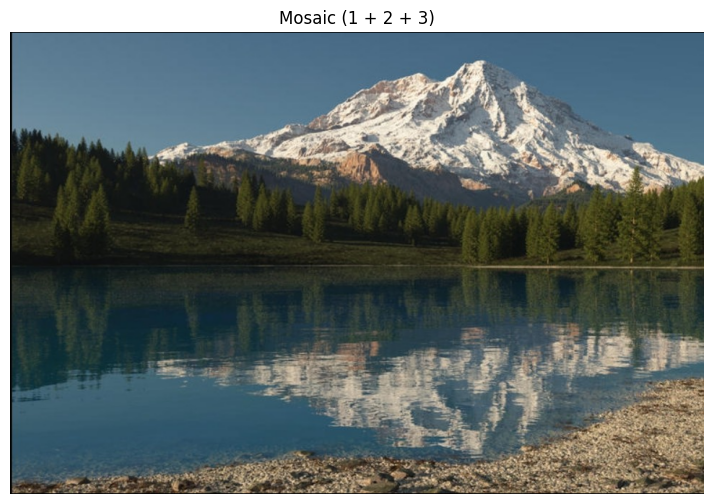

Stitching (1+2+3) with image 4...


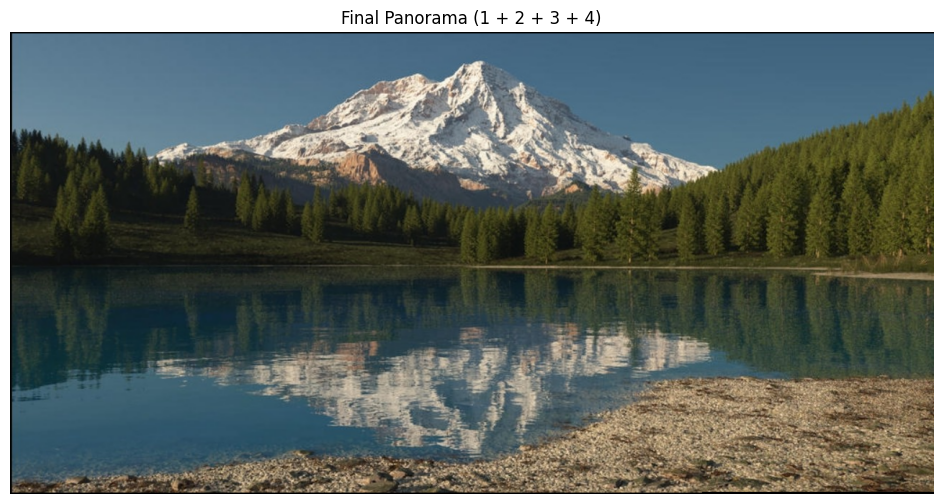


Homography 1→2:
 [[   0.9997     0.00002 -428.86636]
 [  -0.00002    0.99975   45.00498]
 [  -0.        -0.         1.     ]]

Homography (12)→3:
 [[   1.00036    0.      -322.13535]
 [   0.00009    1.00019   -0.03146]
 [   0.        -0.         1.     ]]

Homography (123)→4:
 [[   0.99991   -0.00002 -486.95484]
 [   0.00001    0.99992   -1.00967]
 [  -0.        -0.         1.     ]]


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, img_rgb):
    """Display image (already RGB) correctly using matplotlib."""
    plt.figure(figsize=(12, 6))
    plt.imshow(img_rgb)   # No conversion needed!
    plt.title(title)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    # --- Image paths ---
    img1_path = "View_1.jpeg"   # leftmost
    img2_path = "View_2.jpeg"   # right
    img3_path = "right.jpeg"    # middle
    img4_path = "Mid.jpeg"      # middle

    # --- Load images ---
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    img3 = cv2.imread(img3_path)
    img4 = cv2.imread(img4_path)

    if any(i is None for i in [img1, img2, img3, img4]):
        raise SystemExit("Could not read one or more input images. Check file paths and names.")

    # --- Step 1: Stitch image 1 + 2 ---
    print("Stitching first two images (1 and 2)...")
    mosaic12, H12, inlier_data12 = stitch(img1, img2, ratio=0.75, ransac_thresh=3.0, ransac_iters=2000)
    show_image("Mosaic (1 + 2)", mosaic12)

    # --- Step 2: Stitch (1+2) with image 3 ---
    print("Stitching the mosaic (1+2) with image 3...")
    mosaic123, H123, inlier_data123 = stitch(img3, img4, ratio=0.75, ransac_thresh=3.0, ransac_iters=2000)
    show_image("Mosaic (1 + 2 + 3)", mosaic123)

    # --- Step 3: Stitch the result with image 4 ---
    print("Stitching (1+2+3) with image 4...")
    mosaic123_bgr = cv2.cvtColor(mosaic123, cv2.COLOR_RGB2BGR)  # Convert back to BGR
    final_mosaic, H_final, inlier_data_final = stitch(mosaic123_bgr, img2, ratio=0.75, ransac_thresh=3.0, ransac_iters=2000)
    show_image("Final Panorama (1 + 2 + 3 + 4)", final_mosaic)

    # --- Print homographies ---
    np.set_printoptions(precision=5, suppress=True)
    print("\nHomography 1→2:\n", H12)
    print("\nHomography (12)→3:\n", H123)
    print("\nHomography (123)→4:\n", H_final)
